In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [2]:
import neuroboros as nb
import numpy as np
from scipy.stats import ttest_rel

/dartfs-hpc/rc/home/q/f007d9q/neuroboros/src/neuroboros/io.py:56: UserWarning: DataLad dataset core exists at /dartfs-hpc/rc/home/q/f007d9q/.neuroboros-data/core, but does not have source https://gin.g-node.org/neuroboros/core as a sibling.
  warnings.warn(


In [34]:
results = nb.load('summary/pred_camcan/results.pkl')

In [35]:
list(results)

[('young', 'young'),
 ('mid', 'young'),
 ('old', 'young'),
 ('young', 'mid'),
 ('mid', 'mid'),
 ('old', 'mid'),
 ('young', 'old'),
 ('mid', 'old'),
 ('old', 'old')]

In [5]:
results

{('young',
  'young'): {'CC110056': [array([0.37436836, 0.62233787, 0.36380727, ..., 0.20294006, 0.30659098,
          0.26356876]),
   array([0.31392585, 0.62345232, 0.32637704, ..., 0.11091119, 0.26728096,
          0.3414943 ]),
   array([0.35205667, 0.58542041, 0.35996393, ..., 0.12562491, 0.27734675,
          0.4118707 ])], 'CC110098': [array([0.48681884, 0.72984668, 0.54786055, ..., 0.47253753, 0.2565173 ,
          0.46456249]),
   array([0.48338536, 0.72310238, 0.57506287, ..., 0.4592805 , 0.33205384,
          0.39585113]),
   array([0.40717363, 0.72609135, 0.59692828, ..., 0.47222938, 0.29294088,
          0.3993138 ]),
   array([0.41327441, 0.74199824, 0.52683612, ..., 0.41932624, 0.25620268,
          0.3985906 ]),
   array([0.45553534, 0.75354983, 0.5535727 , ..., 0.43390407, 0.36128083,
          0.43659016]),
   array([0.44814521, 0.73729289, 0.57872411, ..., 0.46311176, 0.23319398,
          0.47073143])], 'CC110101': [array([ 0.20877904, -0.00302179,  0.25668809, ...,

In [6]:
zz = {}
for test_grp in ['mid', 'young']:
    sids = set([str(_) for _ in results[test_grp, 'young']]) & set([str(_) for _ in results[test_grp, 'mid']])
    for tpl_grp in ['mid', 'young']:
        key = (test_grp, tpl_grp)
        res = results[key]
        zz[key] = np.stack([np.arctanh(res[_]).mean(axis=0) for _ in sids])

In [7]:
zz['mid', 'mid'].shape

(210, 19341)

In [8]:
colors = [mpl.colors.to_rgb(mpl.colors.cnames[_])
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]

config = [
    [0, zz['mid', 'mid']],
    [1, zz['mid', 'young']],
    [2.5, zz['young', 'young']],
    [3.5, zz['young', 'mid']],
]

In [9]:
d1 = (zz['mid', 'mid'] - zz['mid', 'young']).mean(axis=1)
d2 = (zz['young', 'young'] - zz['young', 'mid']).mean(axis=1)

m1 = d1.mean()
se1 = d1.std(ddof=1) / np.sqrt(len(d1))
m2 = d2.mean()
se2 = d2.std(ddof=1) / np.sqrt(len(d2))

In [10]:
print(m1)
print(se1)
print(m2)
print(se2)

0.0013735936381909456
0.00026501726295171784
0.0033908432882477487
0.00019763152893146233


In [11]:
colors = [np.array(mpl.colors.to_rgb(mpl.colors.cnames[_]))
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]
c1 = (colors[0] + colors[1]) * 0.5
c2 = (colors[2] + colors[3]) * 0.5

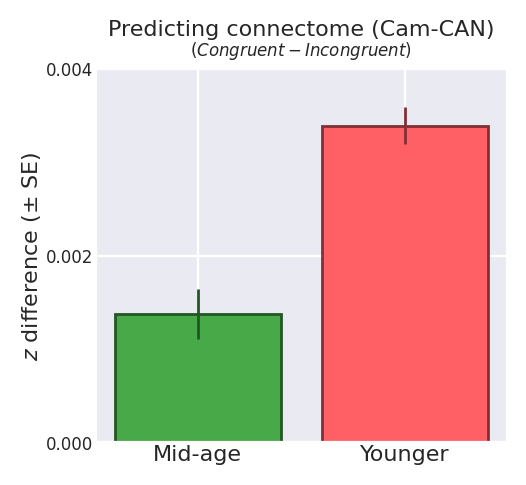

In [31]:
with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [8, 8]], dpi=200)
    
    kwargs = dict(fmt='', lw=1)
    ax.bar(0, m1, color=c1, ec=c1*0.5)
    ax.bar(1, m2, color=c2, ec=c2*0.5)
    ax.errorbar(0, m1, yerr=se1, c=c1*0.5, **kwargs)
    ax.errorbar(1, m2, yerr=se2, c=c2*0.5, **kwargs)
    
    ax.set_ylim(0, 0.004)  
    ax.set_yticks([0, 0.002, 0.004]) 

    ax.tick_params(size=0, pad=1, labelsize=6)
    ax.set_xticks([0, 1], labels=['Mid-age', 'Younger'], size=8)
    ax.set_ylabel('$z$ difference (± SE)', size=8, labelpad=1)
    
    # --- Main Title ---
    ax.set_title('Predicting connectome (Cam-CAN)', size=8, pad=12)
    
    # --- Smaller Subtitle ---
    # We place this at x=0.5 (center) and y=1.02 (just above the axes)
    ax.text(0.5, 1.02, '$(Congruent - Incongruent)$', 
            fontsize=6, ha='center', va='bottom', transform=ax.transAxes)

    # Lower 'top' to 0.82 to ensure both lines are visible
    fig.subplots_adjust(left=0.18, top=0.82, bottom=0.12, right=0.95)
    
    plt.savefig('figures/pred_diff_camcan_mid&young.png', dpi=300, bbox_inches='tight')
    plt.show()

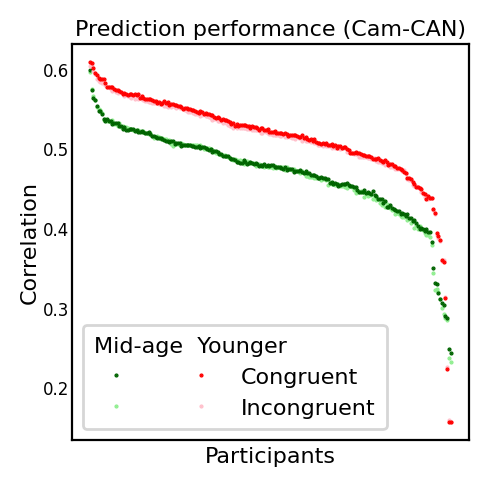

In [15]:
fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
handles = []
for ii, (a, b) in enumerate([[zz['mid', 'mid'], zz['mid', 'young']], [zz['young', 'young'], zz['young', 'mid']]]):
    a, b = a.mean(axis=1), b.mean(axis=1)
    idx = np.argsort((a + b))[::-1]
    a, b = np.tanh(a[idx]), np.tanh(b[idx])
    x = np.arange(len(a))
    kwargs = dict(markersize=1)
    handles += ax.plot(x, b, '.', color=colors[ii*2+1], **kwargs)
    handles += ax.plot(x, a, '.', color=colors[ii*2], **kwargs)
handles = [handles[_] for _ in [1, 0, 3, 2]]
ax.tick_params(size=0, pad=1, labelsize=6)
ax.set_ylabel('Correlation', size=8, labelpad=1)
ax.set_xticks([])
ax.set_xlabel('Participants', size=8, labelpad=2)
ax.set_title('Prediction performance (Cam-CAN)', size=8, pad=3)
ax.legend(handles=handles, labels=['', '', 'Congruent', 'Incongruent'], ncols=2, columnspacing=1, fontsize=8,
         title='Mid-age  Younger', title_fontsize=8, alignment='left', borderpad=0.5, fancybox=True)
fig.subplots_adjust(left=0.13, top=0.92, bottom=0.07, right=0.98)
plt.savefig('figures/pred_dist_camcan_mid&young.png', dpi=300)
plt.show()

In [37]:
zz = {}
for test_grp in ['mid', 'old']:
    sids = set([str(_) for _ in results[test_grp, 'mid']]) & set([str(_) for _ in results[test_grp, 'old']])
    for tpl_grp in ['mid', 'old']:
        key = (test_grp, tpl_grp)
        res = results[key]
        zz[key] = np.stack([np.arctanh(res[_]).mean(axis=0) for _ in sids])

In [38]:
colors = [mpl.colors.to_rgb(mpl.colors.cnames[_])
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]

config = [
    [0, zz['old', 'old']],
    [1, zz['old', 'mid']],
    [2.5, zz['mid', 'mid']],
    [3.5, zz['mid', 'old']],
]

In [40]:
d1 = (zz['old', 'old'] - zz['old', 'mid']).mean(axis=1)
d2 = (zz['mid', 'mid'] - zz['mid', 'old']).mean(axis=1)

m1 = d1.mean()
se1 = d1.std(ddof=1) / np.sqrt(len(d1))
m2 = d2.mean()
se2 = d2.std(ddof=1) / np.sqrt(len(d2))

In [41]:
print(m1)
print(se1)
print(m2)
print(se2)

0.005604074037615307
0.000420272959603568
0.005070013880661074
0.0002481809572187545


In [42]:
colors = [np.array(mpl.colors.to_rgb(mpl.colors.cnames[_]))
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]
c1 = (colors[0] + colors[1]) * 0.5
c2 = (colors[2] + colors[3]) * 0.5

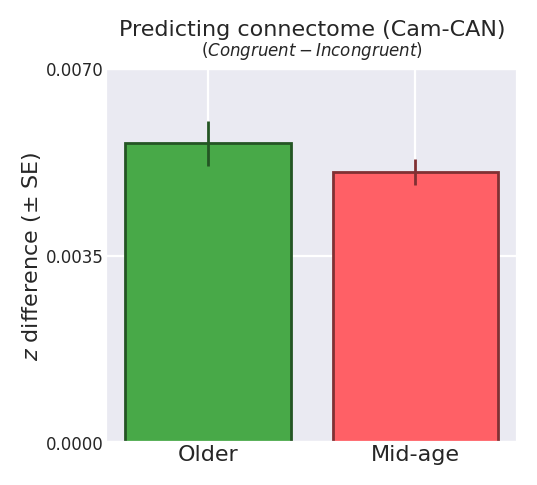

In [45]:
with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [8, 8]], dpi=200)
    
    kwargs = dict(fmt='', lw=1)
    ax.bar(0, m1, color=c1, ec=c1*0.5)
    ax.bar(1, m2, color=c2, ec=c2*0.5)
    ax.errorbar(0, m1, yerr=se1, c=c1*0.5, **kwargs)
    ax.errorbar(1, m2, yerr=se2, c=c2*0.5, **kwargs)
    
    ax.set_ylim(0, 0.007)  
    ax.set_yticks([0, 0.0035, 0.007]) 

    ax.tick_params(size=0, pad=1, labelsize=6)
    ax.set_xticks([0, 1], labels=['Older', 'Mid-age'], size=8)
    ax.set_ylabel('$z$ difference (± SE)', size=8, labelpad=1)
    
    # --- Main Title ---
    ax.set_title('Predicting connectome (Cam-CAN)', size=8, pad=12)
    
    # --- Smaller Subtitle ---
    # We place this at x=0.5 (center) and y=1.02 (just above the axes)
    ax.text(0.5, 1.02, '$(Congruent - Incongruent)$', 
            fontsize=6, ha='center', va='bottom', transform=ax.transAxes)

    # Lower 'top' to 0.82 to ensure both lines are visible
    fig.subplots_adjust(left=0.18, top=0.82, bottom=0.12, right=0.95)
    
    plt.savefig('figures/pred_diff_camcan_mid&old.png', dpi=300, bbox_inches='tight')
    plt.show()

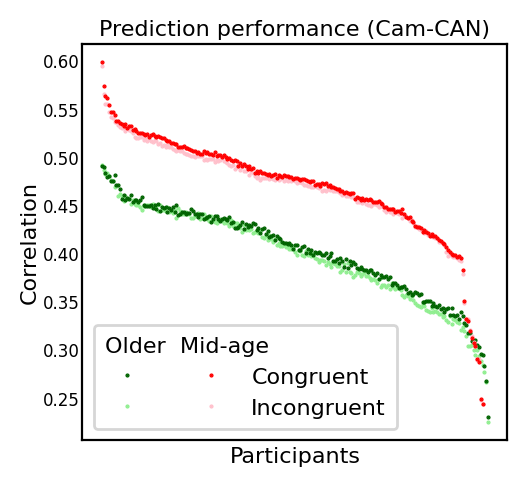

In [49]:
fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7.5, 7]], dpi=200)
handles = []
for ii, (a, b) in enumerate([[zz['old', 'old'], zz['old', 'mid']], [zz['mid', 'mid'], zz['mid', 'old']]]):
    a, b = a.mean(axis=1), b.mean(axis=1)
    idx = np.argsort((a + b))[::-1]
    a, b = np.tanh(a[idx]), np.tanh(b[idx])
    x = np.arange(len(a))
    kwargs = dict(markersize=1)
    handles += ax.plot(x, b, '.', color=colors[ii*2+1], **kwargs)
    handles += ax.plot(x, a, '.', color=colors[ii*2], **kwargs)
handles = [handles[_] for _ in [1, 0, 3, 2]]
ax.tick_params(size=0, pad=1, labelsize=6)
ax.set_ylabel('Correlation', size=8, labelpad=1)
ax.set_xticks([])
ax.set_xlabel('Participants', size=8, labelpad=2)
ax.set_title('Prediction performance (Cam-CAN)', size=8, pad=3)
ax.legend(handles=handles, labels=['', '', 'Congruent', 'Incongruent'], ncols=2, columnspacing=1, fontsize=8,
         title='Older  Mid-age', title_fontsize=8, alignment='left', borderpad=0.5, fancybox=True)
fig.subplots_adjust(left=0.13, top=0.92, bottom=0.07, right=0.98)
plt.savefig('figures/pred_dist_camcan_mid&old.png', dpi=300)
plt.show()

In [ ]:
with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [8, 8]], dpi=200)
    
    kwargs = dict(fmt='', lw=1)
    ax.bar(0, m1, color=c1, ec=c1*0.5)
    ax.bar(1, m2, color=c2, ec=c2*0.5)
    ax.errorbar(0, m1, yerr=se1, c=c1*0.5, **kwargs)
    ax.errorbar(1, m2, yerr=se2, c=c2*0.5, **kwargs)
    
    ax.set_ylim(0, 0.004)  
    ax.set_yticks([0, 0.002, 0.004]) 

    ax.tick_params(size=0, pad=1, labelsize=6)
    ax.set_xticks([0, 1], labels=['Mid-age', 'Younger'], size=8)
    ax.set_ylabel('$z$ difference (± SE)', size=8, labelpad=1)
    
    # --- Main Title ---
    ax.set_title('Predicting connectome (Cam-CAN)', size=8, pad=12)
    
    # --- Smaller Subtitle ---
    # We place this at x=0.5 (center) and y=1.02 (just above the axes)
    ax.text(0.5, 1.02, '$(Congruent - Incongruent)$', 
            fontsize=6, ha='center', va='bottom', transform=ax.transAxes)

    # Lower 'top' to 0.82 to ensure both lines are visible
    fig.subplots_adjust(left=0.18, top=0.82, bottom=0.12, right=0.95)
    
    plt.savefig('figures/pred_diff_camcan_mid&young.png', dpi=300, bbox_inches='tight')
    plt.show()

In [5]:
zz = {}
for test_grp in ['old', 'young']:
    sids = set([str(_) for _ in results[test_grp, 'young']]) & set([str(_) for _ in results[test_grp, 'old']])
    for tpl_grp in ['old', 'young']:
        key = (test_grp, tpl_grp)
        res = results[key]
        zz[key] = np.stack([np.arctanh(res[_]).mean(axis=0) for _ in sids])

In [6]:
zz['old', 'old'].shape

(213, 19341)

In [7]:
colors = [mpl.colors.to_rgb(mpl.colors.cnames[_])
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]

config = [
    [0, zz['old', 'old']],
    [1, zz['old', 'young']],
    [2.5, zz['young', 'young']],
    [3.5, zz['young', 'old']],
]

In [8]:
d1 = (zz['old', 'old'] - zz['old', 'young']).mean(axis=1)
d2 = (zz['young', 'young'] - zz['young', 'old']).mean(axis=1)

m1 = d1.mean()
se1 = d1.std(ddof=1) / np.sqrt(len(d1))
m2 = d2.mean()
se2 = d2.std(ddof=1) / np.sqrt(len(d2))

In [9]:
print(m1)
print(se1)
print(m2)
print(se2)

0.015375392673296219
0.0007016684184893232
0.014734387464481136
0.0003770941626769598


In [11]:
d2.shape

(210,)

In [12]:
all_diff = np.concatenate([d1,d2])
m = all_diff.mean()
se = all_diff.std(ddof=1) / np.sqrt(len(all_diff))
print(m)
print(se)

0.015057163137005043
0.0003996895815857538


In [9]:
np.sum(d1 > 0)/len(d1)

0.9436619718309859

In [10]:
np.sum(d2 > 0)/len(d2)

0.9857142857142858

In [11]:
len(d1)

213

In [12]:
len(d2)

210

In [9]:
m1

0.015375392673296219

In [10]:
se1

0.0007016684184893231

In [11]:
m2

0.014734387464481136

In [12]:
se2

0.0003770941626769598

In [58]:
colors = [np.array(mpl.colors.to_rgb(mpl.colors.cnames[_]))
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]
c1 = (colors[0] + colors[1]) * 0.5
c2 = (colors[2] + colors[3]) * 0.5

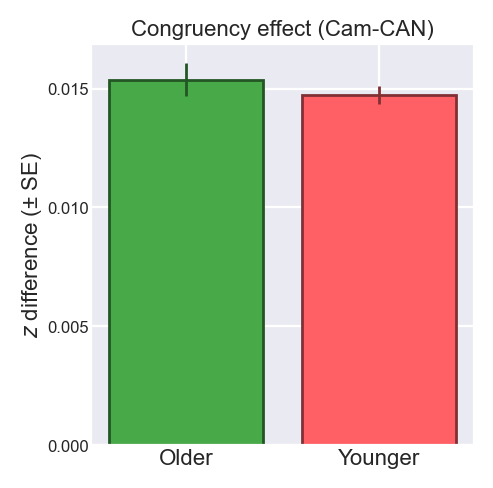

In [64]:
with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
    
    kwargs = dict(fmt='', lw=1)
    ax.bar(0, m1, color=c1, ec=c1*0.5)
    ax.bar(1, m2, color=c2, ec=c2*0.5)
    ax.errorbar(0, m1, yerr=se1, c=c1*0.5, **kwargs)
    ax.errorbar(1, m2, yerr=se2, c=c2*0.5, **kwargs)
    ax.tick_params(size=0, pad=1, labelsize=6)
    ax.set_xticks([0, 1], labels=['Older', 'Younger'], size=8)
    ax.set_ylabel('$z$ difference (± SE)', size=8, labelpad=1)
    ax.set_yticks(np.arange(4)*0.005)
    ax.set_title('Congruency effect (Cam-CAN)', size=8, pad=3)
    fig.subplots_adjust(left=0.16, top=0.92, bottom=0.06, right=0.98)
    plt.savefig('figures/pred_diff_camcan.png', dpi=300)
    plt.show()

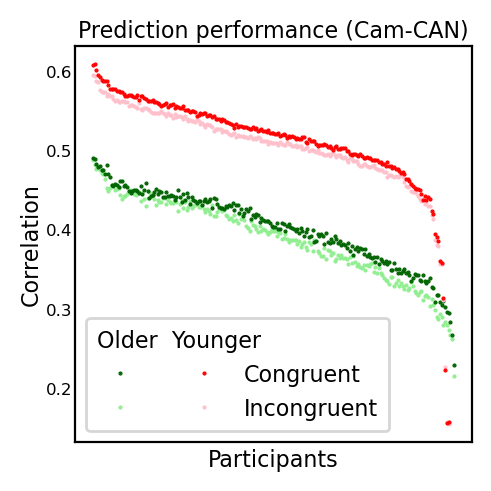

In [73]:
fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
handles = []
for ii, (a, b) in enumerate([[zz['old', 'old'], zz['old', 'young']], [zz['young', 'young'], zz['young', 'old']]]):
    a, b = a.mean(axis=1), b.mean(axis=1)
    idx = np.argsort((a + b))[::-1]
    a, b = np.tanh(a[idx]), np.tanh(b[idx])
    x = np.arange(len(a))
    kwargs = dict(markersize=1)
    handles += ax.plot(x, b, '.', color=colors[ii*2+1], **kwargs)
    handles += ax.plot(x, a, '.', color=colors[ii*2], **kwargs)
handles = [handles[_] for _ in [1, 0, 3, 2]]
ax.tick_params(size=0, pad=1, labelsize=6)
ax.set_ylabel('Correlation', size=8, labelpad=1)
ax.set_xticks([])
ax.set_xlabel('Participants', size=8, labelpad=2)
ax.set_title('Prediction performance (Cam-CAN)', size=8, pad=3)
ax.legend(handles=handles, labels=['', '', 'Congruent', 'Incongruent'], ncols=2, columnspacing=1, fontsize=8,
         title='Older  Younger', title_fontsize=8, alignment='left', borderpad=0.5, fancybox=True)
fig.subplots_adjust(left=0.13, top=0.92, bottom=0.07, right=0.98)
plt.savefig('figures/pred_dist_camcan.png', dpi=300)
plt.show()

[-0.00677774  0.00040831  0.00190056  0.00312682  0.00426622  0.00538788
  0.00657919  0.00783413  0.00958063  0.01242262  0.03227335]


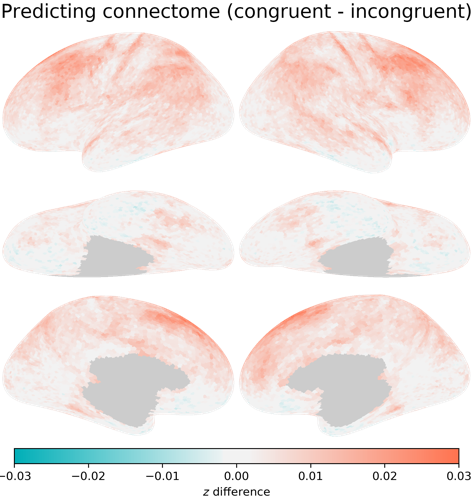

In [71]:
cmap = sns.diverging_palette(200, 20, s=100, l=65, sep=16, as_cmap=True)
c = ((zz['young', 'young'].mean(axis=0) - zz['young', 'old'].mean(axis=0)) + (zz['old', 'old'].mean(axis=0) - zz['old', 'young'].mean(axis=0))) * 0.2
nb.percentile(c)
vmax = 0.03
ic = nb.plot(c, vmax=vmax, vmin=-vmax, cmap=cmap, title = "Predicting connectome (congruent - incongruent)", label='$z$ difference')
ic.save('figures/pred_map_camcan_average.png')
ic

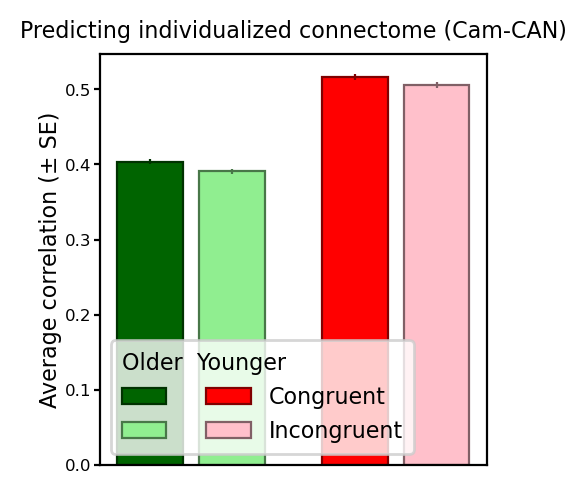

In [40]:
fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)

bars = []
for ii, (x, z) in enumerate(config):
    c = colors[ii]
    ec = 0.5 * np.array(c)
    z = z.mean(axis=1)
    zm = z.mean()
    ze = z.std(ddof=1)/np.sqrt(len(z))
    m = np.tanh(zm)
    yerr = np.abs(np.tanh([zm-ze, zm+ze]) - m)
    b = ax.bar(x, m, color=c, ec=ec, lw=0.8)
    bars.append(b)
    ax.errorbar(x, m, yerr=yerr[:, None], color=ec, lw=0.8)
ax.set_xticks([])
ax.tick_params(size=2, pad=1, labelsize=6)
ax.set_ylabel('Average correlation (± SE)', size=8, labelpad=1)
ax.legend(handles=bars, labels=['', '', 'Congruent', 'Incongruent'], ncols=2, columnspacing=1, fontsize=8,
         title='Older  Younger', title_fontsize=8, alignment='left', borderpad=0.5, fancybox=True)
ax.set_title('Predicting individualized connectome (Cam-CAN)', size=8)
fig.subplots_adjust(left=0.15, right=0.98, top=0.9, bottom=0.02)
plt.savefig('figures/pred_errorbar_camcan.png', dpi=300)
plt.show()

In [52]:
a = np.tanh(zz['old', 'old'].mean(axis=0))
b = np.tanh(zz['old', 'young'].mean(axis=0))
c = (zz['old', 'old'] - zz['old', 'young']).mean(axis=0)
for d in [a, b, c]:
    nb.percentile(d)

[0.02932688 0.29088133 0.32939529 0.35647315 0.3777721  0.40060438
 0.42661955 0.45500334 0.47902119 0.50473571 0.60037697]
[0.03273629 0.28361793 0.31651001 0.34012005 0.36227126 0.38420403
 0.41152533 0.44046389 0.46512023 0.4939568  0.60668666]
[-0.03525016 -0.0030472   0.00199295  0.00580849  0.00958918  0.01356444
  0.01776703  0.02239316  0.0280021   0.03619495  0.09049157]


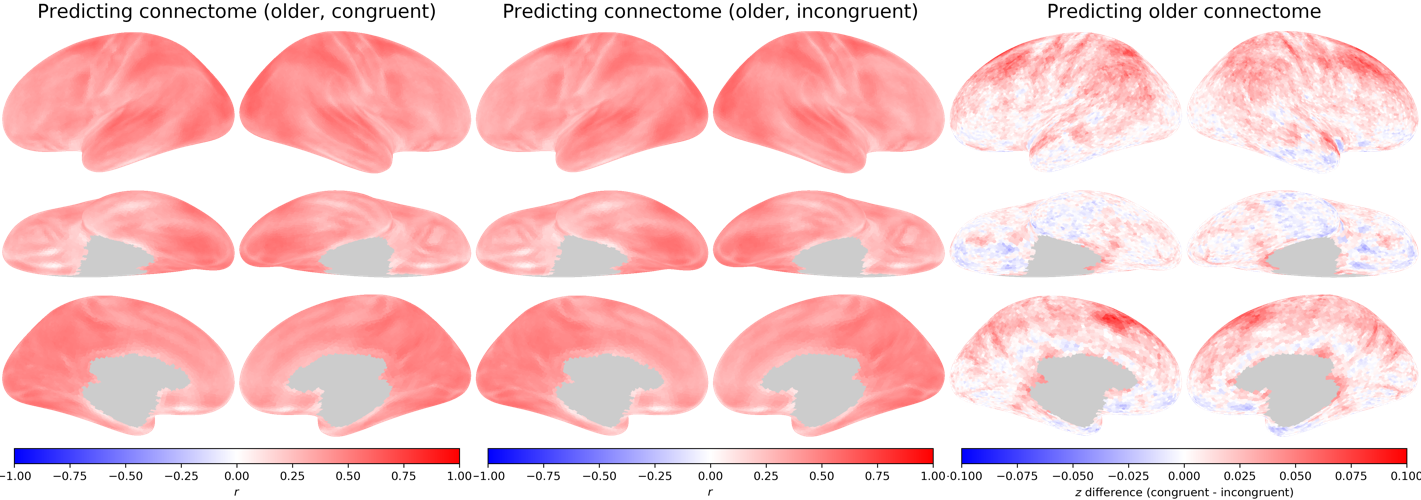

In [53]:
vmax = 1
ia = nb.plot(a, vmax=vmax, vmin=-vmax, cmap='bwr', title = "Predicting connectome (older, congruent)", label='$r$')
ib = nb.plot(b, vmax=vmax, vmin=-vmax, cmap='bwr', title = "Predicting connectome (older, incongruent)", label='$r$')
vmax = 0.1
ic = nb.plot(c, vmax=vmax, vmin=-vmax, cmap='bwr', title = "Predicting older connectome", label='$z$ difference (congruent - incongruent)')
im = nb.Image.hstack([ia, ib, ic])
im.save('figures/pred_map_camcan_older.png')
ic.save('figures/pred_diffmap_camcan_older.png')
im

In [54]:
a = np.tanh(zz['young', 'young'].mean(axis=0))
b = np.tanh(zz['young', 'old'].mean(axis=0))
c = (zz['young', 'young'] - zz['young', 'old']).mean(axis=0)
for d in [a, b, c]:
    nb.percentile(d)

[0.0110615  0.34550976 0.42284933 0.45966578 0.49036589 0.51876539
 0.54750291 0.57649074 0.60810671 0.6504897  0.74531795]
[0.01422386 0.33539989 0.40792286 0.44430428 0.47533516 0.50515059
 0.53480411 0.56698673 0.60102564 0.64340344 0.74327973]
[-0.02959378 -0.00131811  0.00327497  0.00658494  0.00966904  0.01261643
  0.01589034  0.01984427  0.0250733   0.03376193  0.08616815]


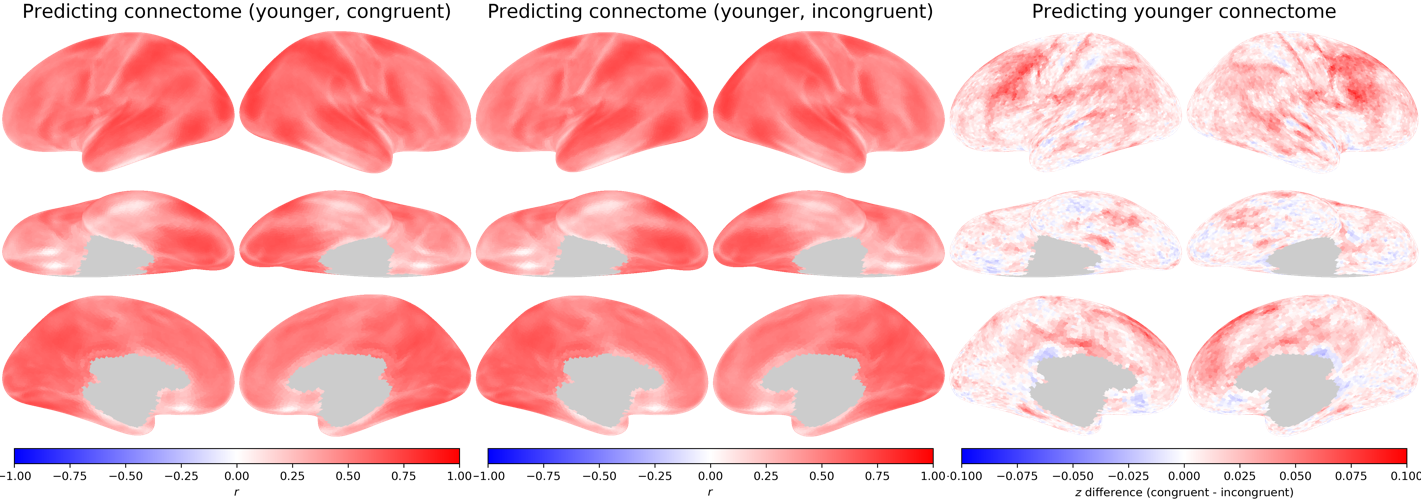

In [55]:
vmax = 1
ia = nb.plot(a, vmax=vmax, vmin=-vmax, cmap='bwr', title = "Predicting connectome (younger, congruent)", label='$r$')
ib = nb.plot(b, vmax=vmax, vmin=-vmax, cmap='bwr', title = "Predicting connectome (younger, incongruent)", label='$r$')
vmax = 0.1
ic = nb.plot(c, vmax=vmax, vmin=-vmax, cmap='bwr', title = "Predicting younger connectome", label='$z$ difference (congruent - incongruent)')
im = nb.Image.hstack([ia, ib, ic])
im.save('figures/pred_map_camcan_younger.png')
ic.save('figures/pred_diffmap_camcan_younger.png')
im